<a href="https://colab.research.google.com/github/AlexMSBA/final_brahma_github/blob/main/decision_tree_and_random_forest_flight_delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BSAN 6070_Spring2026_ML_Final_Project
# ✈️ Flight Delay Prediction — Decision Tree + Random Forest
### Individual Component: Tree-based Classifiers
1.   Feature Selection (mirrored from Section 2.2),
2.   Hub-Airport Filtering, and
3.   Decision Tree + Random Forest training, validation, explainability

**Predictive Question:** Can we predict whether a U.S. domestic flight at one of the six major hub airports (ORD, CLT, LAX, DEN, DFW, ATL) will arrive 15 minutes or more late using airline, route, date, and schedule information from 2018, 2019, 2021, and 2022?

**Target Variable:** `ArrDel15` (1 = delayed ≥15 min, 0 = on time)

**Hub Airports:**
* ORD — O'Hare International (Chicago)
* CLT — Charlotte Douglas International
* LAX — Los Angeles International
* DEN — Denver International
* DFW — Dallas/Fort Worth International
* ATL — Hartsfield-Jackson Atlanta International

### Notebook outline
* Feature Selection: candidate groups inherited from Section 2.2
* Preprocessing decisions (encoding, leakage guard)
* Hub-airport filter (ORD, CLT, LAX, DEN, DFW, ATL)
* Train/Test split support
* Model Assumption Validation
* Individual Model A: Decision Tree
* Individual Model B: Random Forest (same features, same hub filter)
* Feature Importance & Tree Visualization
* Side-by-side model comparison

## Setup & Imports

In [ ]:
# Install any extra libraries not in Colab by default
!pip install graphviz --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier

# Model persistence
import joblib

print("All imports successful ✅")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

All imports successful ✅
Pandas: 2.2.2 | NumPy: 2.0.2


## 1. Data Loading
Load the cleaned/sampled dataset produced from EDA stage

In [ ]:
try:
    df = pd.read_parquet('/content/cleaned_flights.parquet')
    print("Successfully loaded as Parquet.")
except Exception as e:
    print(f"Could not load as Parquet: {e}")
    print("Attempting to load as CSV...")
    try:
        df = pd.read_csv('/content/cleaned_flights.parquet') # Try reading as CSV
        print("Successfully loaded as CSV.")
    except Exception as e_csv:
        print(f"Could not load as CSV either: {e_csv}")
        print("Please check the file format. It might be corrupted or a different format than expected.")
        df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

if not df.empty:
    print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    display(df.head())
else:
    print("DataFrame is empty or could not be loaded.")

Successfully loaded as Parquet.
Dataset loaded: 9,668,554 rows, 17 columns


,FlightDate,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operating_Airline,Origin,Dest,Distance,DistanceGroup,CRSDepTime,CRSArrTime,CRSElapsedTime,DepTimeBlk,ArrDel15
0,2021-04-15,2021,2,4,15,4,WN,WN,PVD,TPA,1136.0,5,1155,1500,185.0,1100-1159,0.0
1,2021-09-29,2021,3,9,29,3,F9,F9,PHL,DEN,1558.0,7,2006,2225,259.0,2000-2059,0.0
2,2018-08-01,2018,3,8,1,3,WN,WN,AUS,ELP,528.0,3,540,605,85.0,0001-0559,0.0
3,2022-05-21,2022,2,5,21,6,DL,9E,ATL,SHV,551.0,3,2245,2335,110.0,2200-2259,0.0
4,2018-04-29,2018,2,4,29,7,AS,AS,SEA,OAK,672.0,3,1535,1737,122.0,1500-1559,0.0


## 2. Feature Selection: Process, rationale and methodology
* Part of deliverables, Discuss in the report and slide

Covers: leakage removal, candidate feature identification, hub-airport filtering, final feature set justification.

### 2.1 Step 1: Remove leakage variables
These columns reveal the answer (arrival delay) directly or are only known *after* landing. They are excluded before any modeling.

In [ ]:
# Columns that cause data leakage, known only AFTER the flight lands
LEAKAGE_COLS = [
    'ArrDelay', 'ArrDel15',          # Target proxy, direct leakage
    'ArrTime', 'ActualElapsedTime',   # Post-arrival info
    'AirTime', 'WheelsOn', 'TaxiIn', # Post-arrival operational
    'ArrivalDelayGroups', 'ArrTimeBlk',
    'Cancelled', 'Diverted',          # If flight is cancelled/diverted, no ArrDel15
    # Other Post-departure variable (shall be considered for removal when predicting BEFORE departure):
    # 'DepDelay', 'DepDel15', 'TaxiOut', 'WheelsOff', 'DepTime'
]

TARGET = 'ArrDel15'

# Separate target before dropping
y = df[TARGET].copy()
X_raw = df.drop(columns=LEAKAGE_COLS + [col for col in LEAKAGE_COLS if col != TARGET], errors='ignore')

print(f"Target variable class distribution:")
print(y.value_counts(normalize=True).round(3))
print(f"\nFeatures remaining after leakage removal: {X_raw.shape[1]}")

Target variable class distribution:
ArrDel15
0.0    0.808
1.0    0.192
Name: proportion, dtype: float64

Features remaining after leakage removal: 16


### 2.2 Step 2: Defining candidate features
Grouping features into logical categories before selection. (Mirrored from the team's master notebook — Section 2.2)

In [ ]:
# CANDIDATE FEATURE GROUPS
TEMPORAL_FEATURES   = ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
SCHEDULE_FEATURES   = ['CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'DepTimeBlk']
ROUTE_FEATURES      = ['Origin', 'Dest', 'Distance', 'DistanceGroup']
AIRLINE_FEATURES    = ['Marketing_Airline_Network', 'Operating_Airline']
DEPARTURE_FEATURES  = ['DepDelay', 'DepDel15', 'TaxiOut']  # Only for predicting AT departure time

# DepDelay & DepDel15 are strong predictors but only valid for an AT-departure prediction scenario (not pre-departure).

ALL_CANDIDATES = TEMPORAL_FEATURES + SCHEDULE_FEATURES + ROUTE_FEATURES + AIRLINE_FEATURES
# Departure features will only added for AT-departure prediction: ALL_CANDIDATES + DEPARTURE_FEATURES

print("Candidate features by group:")
for grp, feats in [
    ('Temporal', TEMPORAL_FEATURES),
    ('Schedule', SCHEDULE_FEATURES),
    ('Route', ROUTE_FEATURES),
    ('Airline', AIRLINE_FEATURES),
    ('Departure (conditional)', DEPARTURE_FEATURES)
]:
    print(f"  {grp}: {feats}")

Candidate features by group:
  Temporal: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
  Schedule: ['CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'DepTimeBlk']
  Route: ['Origin', 'Dest', 'Distance', 'DistanceGroup']
  Airline: ['Marketing_Airline_Network', 'Operating_Airline']
  Departure (conditional): ['DepDelay', 'DepDel15', 'TaxiOut']


### 2.3 Step 3: Hub-Airport Filtering
Restrict the analysis to flights operating through six major U.S. hub airports. This produces a focused, comparable set of routes — the busiest hubs in the country — and reduces categorical cardinality on `Origin` / `Dest` for both tree-based models.

In [ ]:
# HUB AIRPORTS to keep
HUB_AIRPORTS = ['ORD', 'CLT', 'LAX', 'DEN', 'DFW', 'ATL']
# ORD = O'Hare (Chicago)
# CLT = Charlotte Douglas
# LAX = Los Angeles
# DEN = Denver
# DFW = Dallas/Fort Worth
# ATL = Hartsfield-Jackson Atlanta

# Keep flights where EITHER origin OR destination is a hub airport
hub_mask = df['Origin'].isin(HUB_AIRPORTS) | df['Dest'].isin(HUB_AIRPORTS)
df_hub = df[hub_mask].copy()

print(f"Original dataset shape : {df.shape}")
print(f"Hub-filtered shape     : {df_hub.shape}")
print(f"Reduction              : {(1 - len(df_hub)/len(df))*100:.1f}% rows dropped")

print("\nFlight counts per hub (Origin):")
print(df_hub[df_hub['Origin'].isin(HUB_AIRPORTS)]['Origin'].value_counts())

print("\nFlight counts per hub (Dest):")
print(df_hub[df_hub['Dest'].isin(HUB_AIRPORTS)]['Dest'].value_counts())

Original dataset shape : (9668554, 17)
Hub-filtered shape     : (4223429, 17)
Reduction              : 56.3% rows dropped

Flight counts per hub (Origin):
Origin
ORD    460634
ATL    446389
DEN    385632
DFW    351603
CLT    288821
LAX    287436
Name: count, dtype: int64

Flight counts per hub (Dest):
Dest
ORD    459288
ATL    446718
DEN    386581
DFW    352139
CLT    288906
LAX    286649
Name: count, dtype: int64


## 3. Preprocessing
* Discuss below in the report

> Covers: encoding strategy, missing value handling, scaling decisions (not needed for tree-based models), class imbalance handling.

In [ ]:
# Select only candidate features from the hub-filtered dataframe
available_candidates = [c for c in ALL_CANDIDATES if c in df_hub.columns]
X = df_hub[available_candidates].copy()
y = df_hub[TARGET].copy()

# Drop rows where target is missing
mask = y.notna()
X, y = X[mask], y[mask]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nMissing values per feature:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Feature matrix shape: (4129433, 15)
Target shape: (4129433,)

Missing values per feature:
Series([], dtype: int64)


In [ ]:
# ENCODING
# Tree-based models in scikit-learn require numeric input,
# label encoding works fine because trees split on thresholds, not on magnitude.

CATEGORICAL_COLS = ['Marketing_Airline_Network', 'Operating_Airline',
                    'Origin', 'Dest', 'DepTimeBlk']

label_encoders = {}
for col in CATEGORICAL_COLS:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded '{col}' → {le.classes_[:5]} ... ({len(le.classes_)} unique)")

# Fill any remaining nulls with median
X = X.fillna(X.median(numeric_only=True))

print(f"\nPreprocessed feature matrix shape: {X.shape}")
X.dtypes

Encoded 'Marketing_Airline_Network' → ['AA' 'AS' 'B6' 'DL' 'F9'] ... (11 unique)
Encoded 'Operating_Airline' → ['9E' 'AA' 'AS' 'AX' 'B6'] ... (25 unique)
Encoded 'Origin' → ['ABE' 'ABI' 'ABQ' 'ABY' 'ACK'] ... (317 unique)
Encoded 'Dest' → ['ABE' 'ABI' 'ABQ' 'ABY' 'ACK'] ... (317 unique)
Encoded 'DepTimeBlk' → ['0001-0559' '0600-0659' '0700-0759' '0800-0859' '0900-0959'] ... (19 unique)

Preprocessed feature matrix shape: (4129433, 15)


,0
Year,int64
Quarter,int64
Month,int64
DayofMonth,int64
DayOfWeek,int64
CRSDepTime,int64
CRSArrTime,int64
CRSElapsedTime,float64
DepTimeBlk,int64
Origin,int64


## 4. Train / Test Split

In [ ]:
# Training and Test data split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # Maintain class proportions
)

print(f"Train size : {X_train.shape[0]:,}  ({y_train.mean():.3f} delay rate)")
print(f"Test size  : {X_test.shape[0]:,}  ({y_test.mean():.3f} delay rate)")

# Assess Class imbalance
# For both Decision Trees and Random Forests, the simplest fix is class_weight='balanced'
# (re-weights samples inversely proportional to class frequency)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
imbalance_ratio = neg / pos
print(f"\nClass imbalance ratio (neg/pos): {imbalance_ratio:.2f}  (neg={neg:,} / pos={pos:,})")
print("→ will pass class_weight='balanced' to both models")

Train size : 3,303,546  (0.190 delay rate)
Test size  : 825,887  (0.190 delay rate)

Class imbalance ratio (neg/pos): 4.25  (neg=2,674,252 / pos=629,294)
→ will pass class_weight='balanced' to both models


### Sampling for Quick Iteration

For faster experimentation and hyperparameter tuning, we will define a training data sample of 100,000 rows. This sample will be used for computationally intensive steps like Mutual Information calculation and initial model training. The final evaluation will always be on the full test set.

In [ ]:
# Define a global sample for faster operations
GLOBAL_TRAIN_SAMPLE_SIZE = 100000

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=GLOBAL_TRAIN_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)

print(f"Global training sample size: {len(X_train_sample):,} rows ({y_train_sample.mean():.3f} delay rate)")

Global training sample size: 100,000 rows (0.190 delay rate)


## 5. Model Assumption Validation
*for report slide
>
> Decision Trees and Random Forests have very few statistical assumptions (no normality, no linearity, no scaling required),
> but we still validate the practical modeling conditions below.

In [ ]:
print("=" * 60)
print("MODEL ASSUMPTION/CONDITION CHECKS")
print("=" * 60)

# CHECK 1: Class balance
delay_rate = y_train.mean()
print(f"\n[1] Class balance - delay rate: {delay_rate:.3f}")
if delay_rate < 0.3 or delay_rate > 0.7:
    print("Imbalanced - use class_weight='balanced' or resampling")
else:
    print("Reasonably balanced")

# CHECK 2: No remaining leakage features
remaining = set(X_train.columns)
leakage_check = {'ArrDelay', 'ArrDel15', 'ArrTime', 'AirTime', 'WheelsOn'}
found_leakage = remaining.intersection(leakage_check)
print(f"\n[2] Leakage check — found in X_train: {found_leakage if found_leakage else 'None'}")
print("No leakage" if not found_leakage else " FIX: Remove these columns!")

# CHECK 3: Feature cardinality
print("\n[3] Categorical cardinality check:")
for col in CATEGORICAL_COLS:
    if col in X_train.columns:
        print(f"    {col}: {X_train[col].nunique()} unique values")

# CHECK 4: No all-null columns
null_cols = X_train.columns[X_train.isnull().all()].tolist()
print(f"\n[4] All-null columns: {null_cols if null_cols else 'None '}")

# CHECK 5: Sufficient sample size
print(f"\n[5] Sample size — Train: {X_train.shape[0]:,} | Features: {X_train.shape[1]}")
print("  Sufficient" if X_train.shape[0] > 10000 else "  Small sample")

# CHECK 6: Hub-airport coverage
print("\n[6] Hub-airport coverage in training set:")
if 'Origin' in label_encoders:
    origin_le = label_encoders['Origin']
    hub_codes = [origin_le.transform([h])[0] for h in HUB_AIRPORTS if h in origin_le.classes_]
    hub_train_rows = X_train['Origin'].isin(hub_codes).sum()
    print(f"    Rows where Origin is a hub : {hub_train_rows:,}")

MODEL ASSUMPTION/CONDITION CHECKS

[1] Class balance - delay rate: 0.190
Imbalanced - use class_weight='balanced' or resampling

[2] Leakage check — found in X_train: None
No leakage

[3] Categorical cardinality check:
    Marketing_Airline_Network: 11 unique values
    Operating_Airline: 25 unique values
    Origin: 317 unique values
    Dest: 317 unique values
    DepTimeBlk: 19 unique values

[4] All-null columns: None 

[5] Sample size — Train: 3,303,546 | Features: 15
  Sufficient

[6] Hub-airport coverage in training set:
    Rows where Origin is a hub : 1,738,489


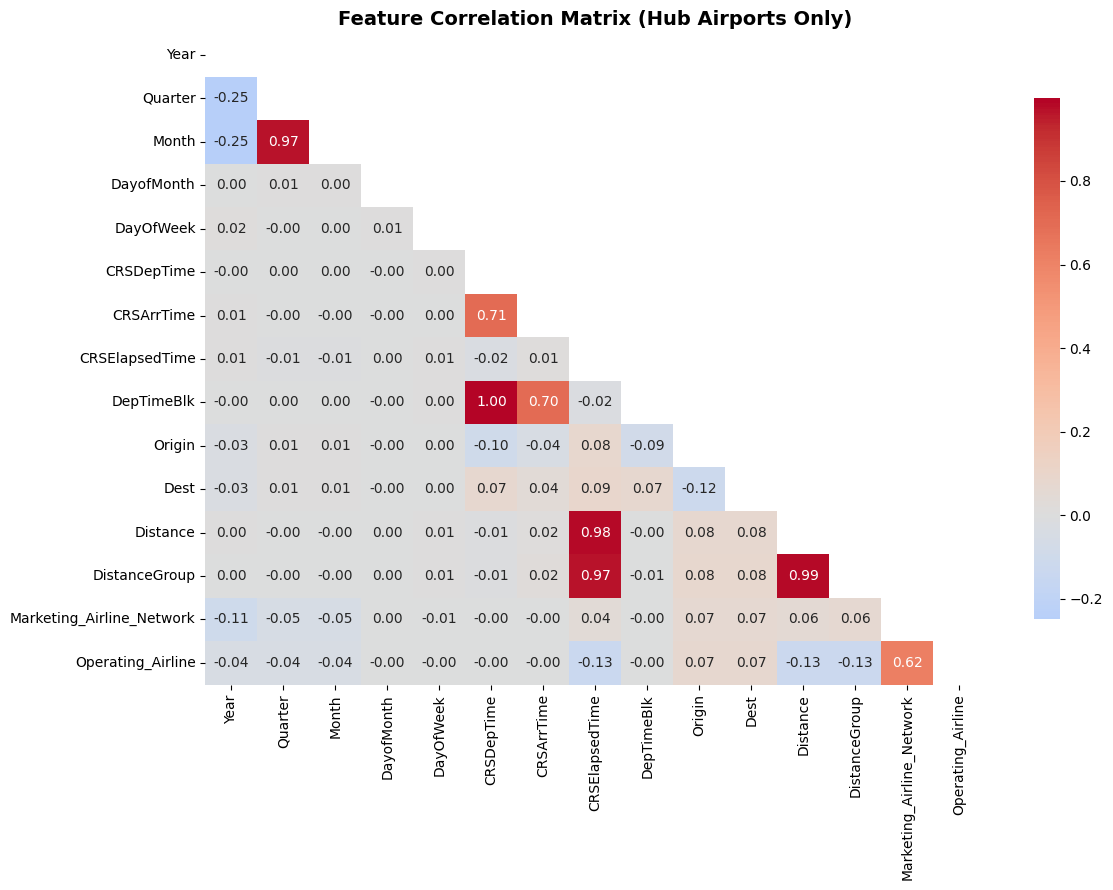

Saved: dt_correlation_heatmap.png


In [ ]:
# Correlation heatmap of numeric features (flag multicollinearity)
# Note: tree models are not sensitive to multicollinearity, but the chart is useful for the report.
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
corr = X_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Hub Airports Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: dt_correlation_heatmap.png")

## 6. Statistical Feature Selection
> *Discuss in the report slide

> Use Mutual Information to rank features, then confirm with model-based importance from the trees.

Top features by Mutual Information:
CRSDepTime                   0.011007
CRSArrTime                   0.010367
DepTimeBlk                   0.009653
Marketing_Airline_Network    0.005966
Operating_Airline            0.005388
Year                         0.005045
Origin                       0.004868
Quarter                      0.004116
Dest                         0.003369
Month                        0.002814
Distance                     0.002762
DistanceGroup                0.001632
CRSElapsedTime               0.001195
DayOfWeek                    0.000067
DayofMonth                   0.000000


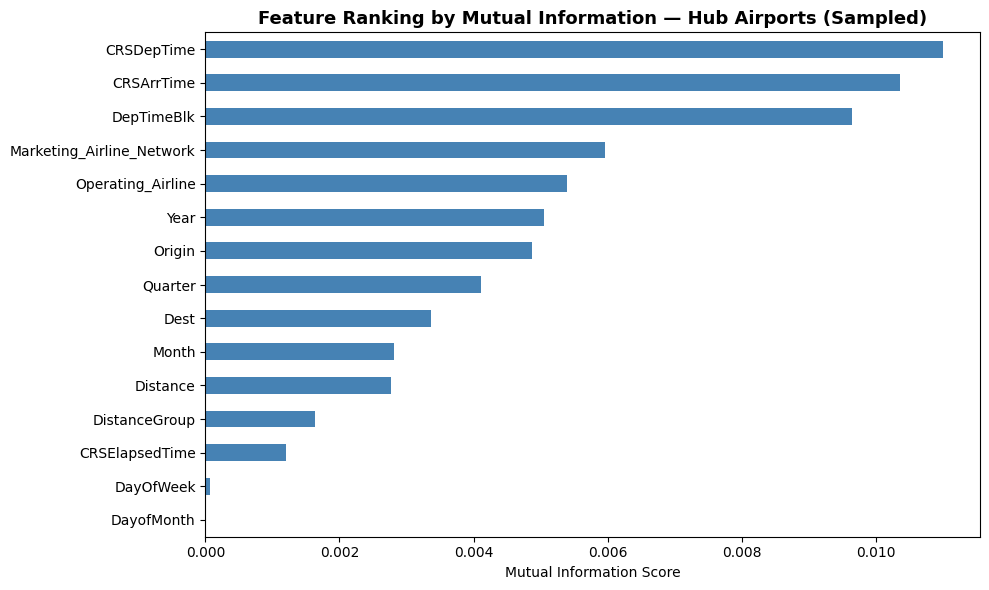

In [ ]:
# Mutual Information scores
# Using the global sample defined for speed

mi_scores = mutual_info_classif(X_train_sample, y_train_sample, random_state=42, n_jobs=-1)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Top features by Mutual Information:")
print(mi_series.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
mi_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Ranking by Mutual Information — Hub Airports (Sampled)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('dt_mutual_info_ranking.png', dpi=150)
plt.show()

## 7. Individual Model A: Decision Tree
> *Individual Component Deliverable — single tree baseline
>
> Justify the model choice, train baseline, tune, evaluate, and explain.

### 7.1 Model Choice Justification

<!--
PLACEHOLDER — write 3–5 sentences here for the report:

A Decision Tree Classifier was selected as the individual model because:
- It produces a fully transparent rule-based structure that non-technical stakeholders
  (airline operations staff, gate agents) can read directly off the diagram
- It handles mixed data types (categorical + numeric) and is invariant to feature scaling
- It captures non-linear interactions between schedule time, day-of-week, and origin/dest
  that linear models like Logistic Regression cannot represent
- It serves as a strong baseline against ensemble methods (Random Forest, XGBoost)
  used elsewhere in the team's project, isolating the marginal value of ensembling
- Limiting `max_depth` and `min_samples_leaf` controls overfitting on the large hub dataset
-->

In [ ]:
# Flag to control training data size for baseline model
USE_FULL_TRAIN_FOR_BASELINE = False  # Set to True to use full X_train/y_train

# BASELINE Decision Tree
dt_baseline = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

if USE_FULL_TRAIN_FOR_BASELINE:
    print(f"Training baseline on full dataset ({len(X_train):,} rows). This may take some time...")
    dt_baseline.fit(X_train, y_train)
else:
    print(f"Training baseline on sampled dataset ({len(X_train_sample):,} rows) for quick iteration.")
    dt_baseline.fit(X_train_sample, y_train_sample)

y_pred_dt = dt_baseline.predict(X_test)
y_prob_dt = dt_baseline.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree Baseline Results ===")
print(classification_report(y_test, y_pred_dt, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"Tree depth     : {dt_baseline.get_depth()}")
print(f"Number of leaves: {dt_baseline.get_n_leaves()}")

Training baseline on sampled dataset (100,000 rows) for quick iteration.

=== Decision Tree Baseline Results ===
              precision    recall  f1-score   support

     On Time       0.86      0.56      0.68    668563
     Delayed       0.25      0.61      0.35    157324

    accuracy                           0.57    825887
   macro avg       0.55      0.58      0.51    825887
weighted avg       0.74      0.57      0.61    825887

ROC-AUC: 0.6190
Tree depth     : 8
Number of leaves: 208


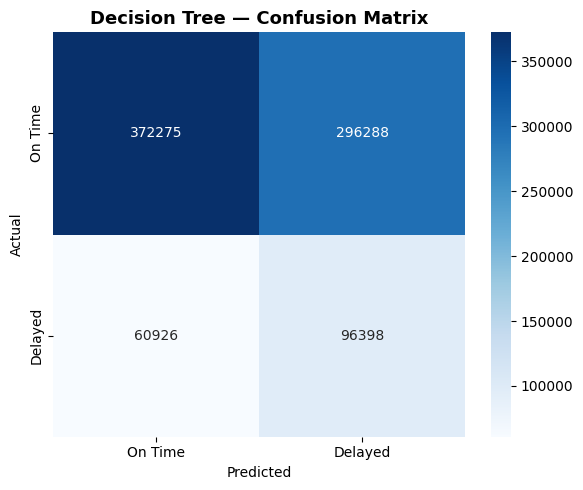

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=ax)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()

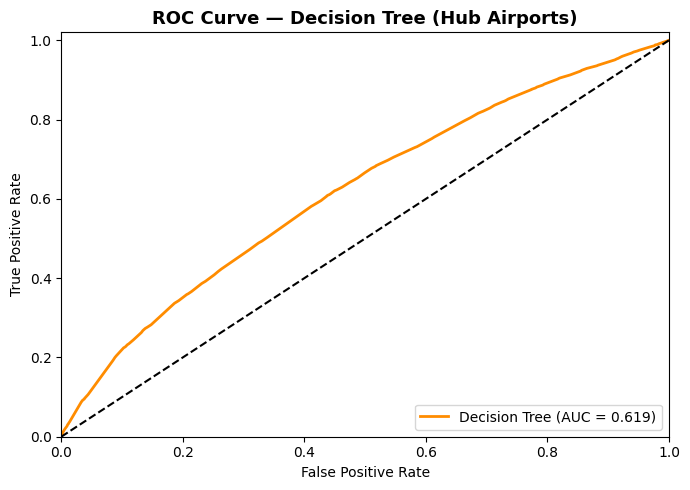

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc_score = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Decision Tree (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Decision Tree (Hub Airports)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=150)
plt.show()

Top 10 Features by Decision Tree Gini Importance:
                  Feature  Importance
               CRSDepTime    0.356735
                    Month    0.163438
               CRSArrTime    0.099818
Marketing_Airline_Network    0.058596
                     Year    0.055215
                   Origin    0.049835
               DayofMonth    0.049400
                     Dest    0.043031
        Operating_Airline    0.040800
                 Distance    0.033168


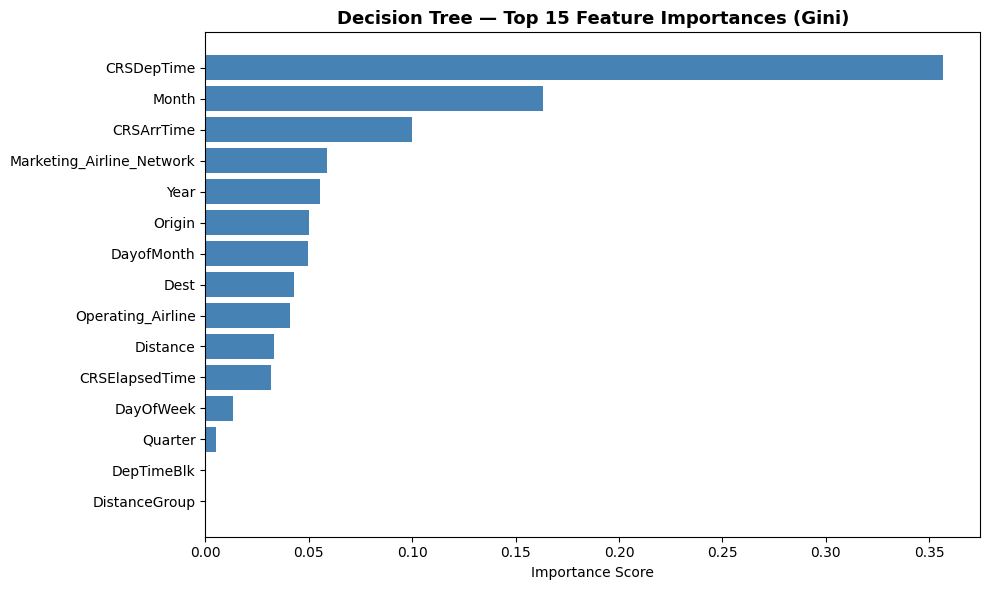

In [ ]:
# Built-in Feature Importance (Gini-based)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Features by Decision Tree Gini Importance:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_n = importance_df.head(15)
ax.barh(top_n['Feature'][::-1], top_n['Importance'][::-1], color='steelblue')
ax.set_title('Decision Tree — Top 15 Feature Importances (Gini)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150)
plt.show()

### 7.2 Tree Visualization
> A Decision Tree's biggest advantage over XGBoost / Random Forest is direct interpretability.
> We render the top levels of the tree so the report can show actual decision rules.

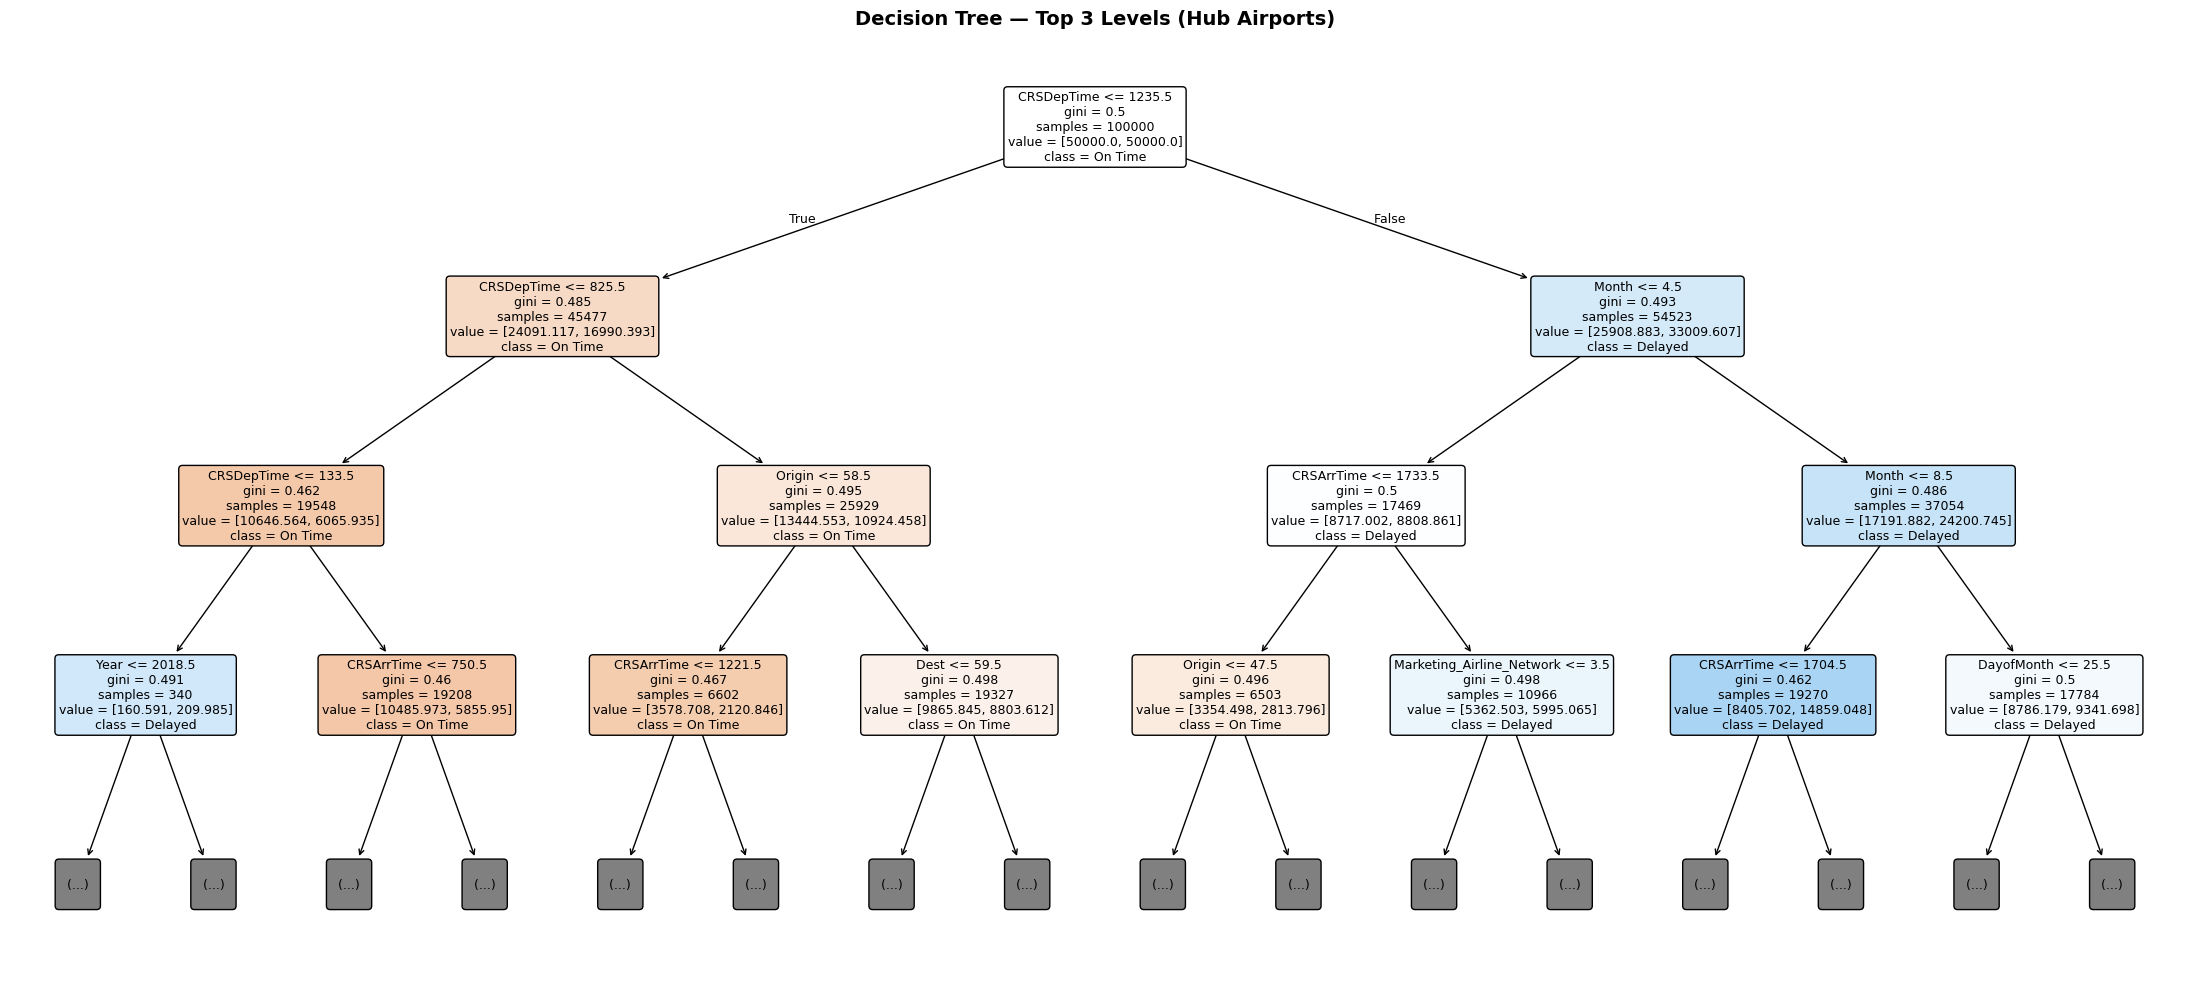

Saved: dt_tree_visualization.png


In [ ]:
# Plot tree (top 3 levels for readability)
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_baseline,
    max_depth=3,                              # cap visualization depth
    feature_names=X_train.columns.tolist(),
    class_names=['On Time', 'Delayed'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels (Hub Airports)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dt_tree_visualization.png")

Permutation Importance (drop in ROC-AUC when feature is shuffled):
                  Feature  Mean_Drop_in_AUC      Std
               CRSDepTime          0.066907 0.004365
                    Month          0.026511 0.003111
               CRSArrTime          0.019604 0.000843
Marketing_Airline_Network          0.012891 0.001039
                   Origin          0.007536 0.001463
                     Year          0.007236 0.003036
                     Dest          0.005283 0.001333
        Operating_Airline          0.004145 0.000669
               DayofMonth          0.003164 0.001366
                  Quarter          0.001044 0.000406
                 Distance          0.000638 0.001344
                DayOfWeek          0.000634 0.000937
               DepTimeBlk          0.000000 0.000000
            DistanceGroup          0.000000 0.000000
           CRSElapsedTime         -0.001212 0.000825


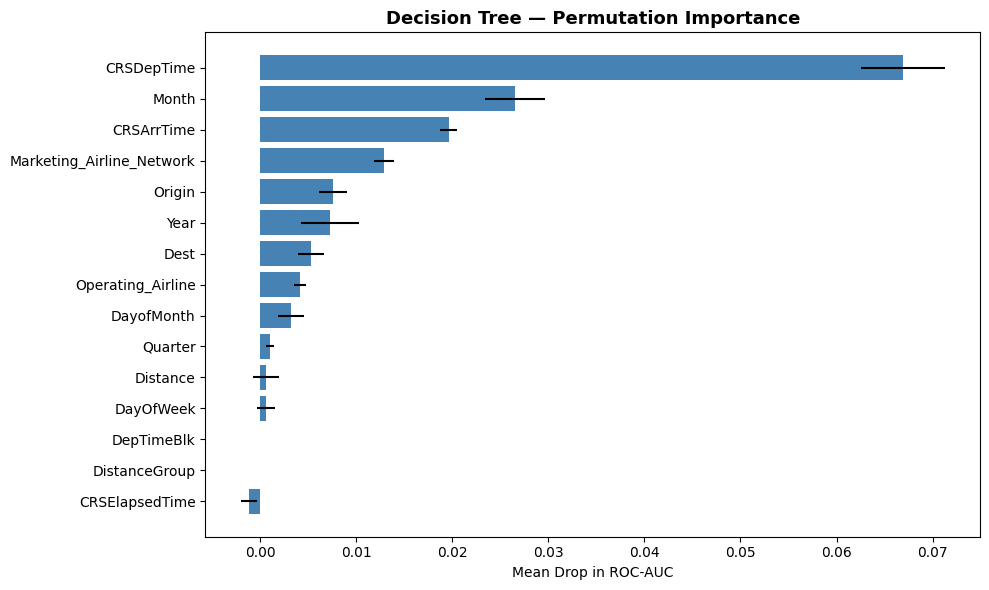

In [ ]:
# Permutation Importance (model-agnostic, more reliable than Gini for high-cardinality columns)
# Run on a sample for speed
sample_size = min(20000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm = permutation_importance(
    dt_baseline, X_test_sample, y_test_sample,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_Drop_in_AUC': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Mean_Drop_in_AUC', ascending=False)

print("Permutation Importance (drop in ROC-AUC when feature is shuffled):")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['Feature'][::-1], perm_df['Mean_Drop_in_AUC'][::-1],
        xerr=perm_df['Std'][::-1], color='steelblue')
ax.set_title('Decision Tree — Permutation Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Drop in ROC-AUC')
plt.tight_layout()
plt.savefig('dt_permutation_importance.png', dpi=150)
plt.show()

---
## 8. Decision Tree — Hyperparameter Tuning
> Tune the Decision Tree. Share with the team for the comparison section.
>
> Use RandomizedSearchCV to efficiently explore the parameter space.

In [ ]:
from scipy.stats import randint

param_dist_dt = {
    'max_depth':         randint(4, 20),
    'min_samples_split': randint(20, 200),
    'min_samples_leaf':  randint(10, 100),
    'criterion':         ['gini', 'entropy'],
    'max_features':      [None, 'sqrt', 'log2'],
}

dt_tuner = RandomizedSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist_dt,
    n_iter=30,           # Increase for thoroughness
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Running on the global training sample for speed
print(f"Running RandomizedSearchCV on sampled dataset ({len(X_train_sample):,} rows).")
dt_tuner.fit(X_train_sample, y_train_sample)

print(f"Best AUC: {dt_tuner.best_score_:.4f}")
print(f"Best params: {dt_tuner.best_params_}")

Running RandomizedSearchCV on sampled dataset (100,000 rows).
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best AUC: 0.6175
Best params: {'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 24, 'min_samples_split': 126}


In [ ]:
# Final tuned Decision Tree evaluation
best_dt = dt_tuner.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

print("=== Tuned Decision Tree Final Results ===")
print(classification_report(y_test, y_pred_best_dt, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best_dt):.4f}")
print(f"Tree depth     : {best_dt.get_depth()}")
print(f"Number of leaves: {best_dt.get_n_leaves()}")

=== Tuned Decision Tree Final Results ===
              precision    recall  f1-score   support

     On Time       0.86      0.56      0.68    668563
     Delayed       0.25      0.61      0.35    157324

    accuracy                           0.57    825887
   macro avg       0.55      0.58      0.52    825887
weighted avg       0.74      0.57      0.62    825887

ROC-AUC: 0.6210
Tree depth     : 7
Number of leaves: 106


In [ ]:
# Save Decision Tree model and artifacts locally in Colab
joblib.dump(best_dt, 'dt_flight_delay_model.pkl')
joblib.dump(label_encoders, 'dt_label_encoders.pkl')
joblib.dump(list(X_train.columns), 'dt_feature_names.pkl')
joblib.dump(HUB_AIRPORTS, 'dt_hub_airports.pkl')

print("✅ Decision Tree artifacts saved successfully to /content/")

✅ Decision Tree artifacts saved successfully to /content/


---
## 9. Decision Tree — Per-Hub Performance Breakdown
> Decompose accuracy / AUC by hub airport so the report can highlight which hubs are easier or harder to predict.

In [ ]:
# Decode Origin back to airport code for the breakdown
origin_le = label_encoders['Origin']
# Ensure we are using the correct array for indexing
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
origin_test_decoded = origin_le.inverse_transform(X_test_reset['Origin'].astype(int))

rows = []
for hub in HUB_AIRPORTS:
    mask = (origin_test_decoded == hub)
    if mask.sum() == 0:
        continue

    yt = y_test_reset[mask]
    yp = y_pred_best_dt[mask]
    yprob = y_prob_best_dt[mask]

    rows.append({
        'Hub (Origin)': hub,
        'N_test': int(mask.sum()),
        'Delay_rate': round(float(yt.mean()), 3),
        'Accuracy':  round(accuracy_score(yt, yp), 3),
        'F1':        round(f1_score(yt, yp), 3),
        'ROC_AUC':   round(roc_auc_score(yt, yprob), 3) if len(np.unique(yt)) > 1 else np.nan,
    })

hub_perf_dt = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
print("Decision Tree — Per-hub performance (origin = hub):")
display(hub_perf_dt)

Decision Tree — Per-hub performance (origin = hub):


,Hub (Origin),N_test,Delay_rate,Accuracy,F1,ROC_AUC
1,CLT,56617,0.188,0.575,0.356,0.629
3,DEN,75460,0.234,0.476,0.398,0.626
5,ATL,88133,0.159,0.726,0.289,0.607
0,ORD,89273,0.229,0.476,0.390,0.601
4,DFW,68294,0.225,0.494,0.379,0.597
2,LAX,56452,0.173,0.503,0.304,0.580


---
## 10. Individual Model B: Random Forest
> Same features (Section 2.2 candidate set), same hub filter, same train/test split, same `class_weight='balanced'` strategy.
>
> Random Forest = bagged ensemble of decorrelated Decision Trees. Each tree's per-tree hyperparameters are kept identical to the DT baseline (`max_depth=8`, `min_samples_split=50`, `min_samples_leaf=25`, `criterion='gini'`) so the only structural change is the ensembling itself.

### 10.1 Model Choice Justification

<!--
PLACEHOLDER — write 3–5 sentences here for the report:

A Random Forest Classifier was added as a second tree-based model because:
- It addresses the high variance / overfitting tendency of a single Decision Tree by
  averaging predictions across many bootstrapped, decorrelated trees
- It uses the SAME features, encoding, hub filter, and per-tree hyperparameters as the
  Decision Tree baseline, isolating the marginal value of ensembling itself
- It still operates on label-encoded categoricals without scaling, so the preprocessing
  pipeline is unchanged
- It exposes both Gini importance and Out-of-Bag (OOB) feature importance for explainability
- It is widely used as the production-grade benchmark before reaching for boosting (XGBoost),
  giving the team a clean comparison point
-->

In [ ]:
# Flag to control training data size for baseline RF
USE_FULL_TRAIN_FOR_RF_BASELINE = False  # Set to True to use full X_train/y_train

# BASELINE Random Forest
# Per-tree parameters mirror the Decision Tree baseline so the comparison is apples-to-apples.
# RF-specific parameters: n_estimators (forest size), bootstrap, max_features.
rf_baseline = RandomForestClassifier(
    n_estimators=200,             # 200 trees in the forest
    max_depth=8,                  # SAME as DT baseline
    min_samples_split=50,         # SAME as DT baseline
    min_samples_leaf=25,          # SAME as DT baseline
    criterion='gini',             # SAME as DT baseline
    max_features='sqrt',          # Standard RF setting — sqrt(n_features) per split
    bootstrap=True,                # Bagging on (defining feature of RF)
    oob_score=True,               # Out-of-Bag estimate as a free validation signal
    class_weight='balanced',      # SAME imbalance handling as DT
    random_state=42,
    n_jobs=-1                     # Parallelize across cores
)

if USE_FULL_TRAIN_FOR_RF_BASELINE:
    print(f"Training RF baseline on full dataset ({len(X_train):,} rows). This may take a while...")
    rf_baseline.fit(X_train, y_train)
else:
    print(f"Training RF baseline on sampled dataset ({len(X_train_sample):,} rows) for quick iteration.")
    rf_baseline.fit(X_train_sample, y_train_sample)

y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Baseline Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC      : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"OOB score    : {rf_baseline.oob_score_:.4f}")
print(f"# of trees   : {len(rf_baseline.estimators_)}")
print(f"Avg depth    : {np.mean([t.get_depth() for t in rf_baseline.estimators_]):.1f}")
print(f"Avg # leaves : {np.mean([t.get_n_leaves() for t in rf_baseline.estimators_]):.1f}")

Training RF baseline on sampled dataset (100,000 rows) for quick iteration.

=== Random Forest Baseline Results ===
              precision    recall  f1-score   support

     On Time       0.86      0.63      0.73    668563
     Delayed       0.26      0.56      0.36    157324

    accuracy                           0.62    825887
   macro avg       0.56      0.60      0.54    825887
weighted avg       0.75      0.62      0.66    825887

ROC-AUC      : 0.6369
OOB score    : 0.6143
# of trees   : 200
Avg depth    : 8.0
Avg # leaves : 191.4


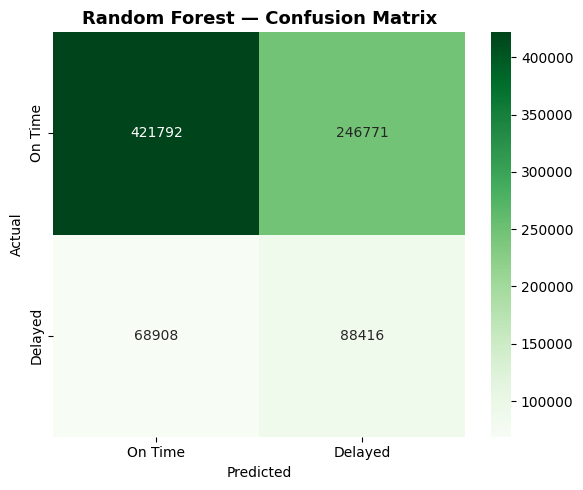

In [ ]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=ax)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

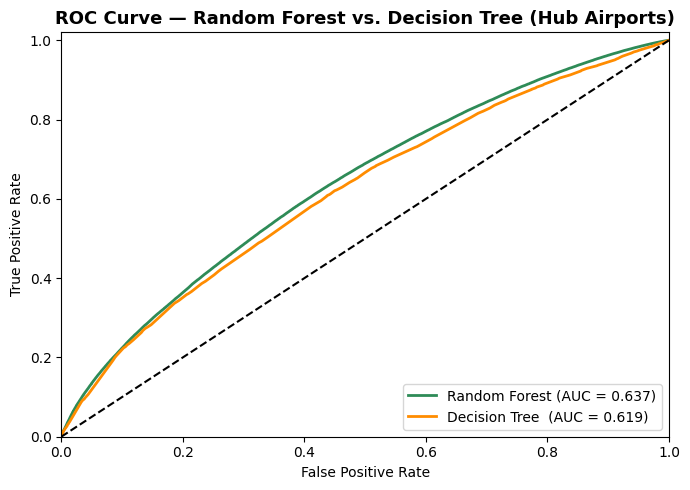

In [ ]:
# ROC Curve — Random Forest (overlaid with Decision Tree for visual comparison)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_rf, tpr_rf, color='seagreen',  lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Decision Tree  (AUC = {auc_dt:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest vs. Decision Tree (Hub Airports)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rf_vs_dt_roc_curve.png', dpi=150)
plt.show()

Top 10 Features by Random Forest Gini Importance:
                  Feature  Importance
               CRSDepTime    0.192777
               CRSArrTime    0.164181
               DepTimeBlk    0.138429
                    Month    0.085171
                   Origin    0.058989
                     Dest    0.052122
        Operating_Airline    0.050866
Marketing_Airline_Network    0.048457
                 Distance    0.041803
               DayofMonth    0.038574


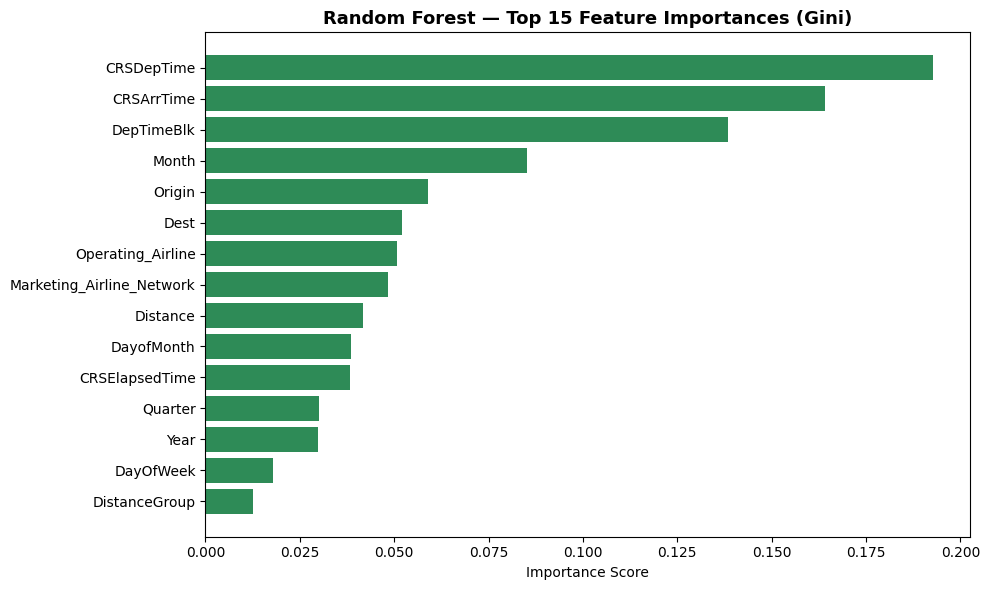

In [ ]:
# Built-in Feature Importance (averaged Gini-based across all trees)
importance_df_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Features by Random Forest Gini Importance:")
print(importance_df_rf.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_n = importance_df_rf.head(15)
ax.barh(top_n['Feature'][::-1], top_n['Importance'][::-1], color='seagreen')
ax.set_title('Random Forest — Top 15 Feature Importances (Gini)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

Random Forest — Permutation Importance (drop in ROC-AUC when feature is shuffled):
                  Feature  Mean_Drop_in_AUC      Std
               CRSDepTime          0.013001 0.001508
                    Month          0.011323 0.000875
Marketing_Airline_Network          0.007864 0.000677
                     Year          0.005298 0.000478
                   Origin          0.004874 0.000590
                     Dest          0.004434 0.000153
               DepTimeBlk          0.004355 0.001377
        Operating_Airline          0.003819 0.000317
               CRSArrTime          0.003513 0.001865
               DayofMonth          0.003153 0.000183
                  Quarter          0.001563 0.000177
                 Distance          0.001053 0.000438
                DayOfWeek          0.000963 0.000196
            DistanceGroup          0.000043 0.000048
           CRSElapsedTime         -0.000123 0.000087


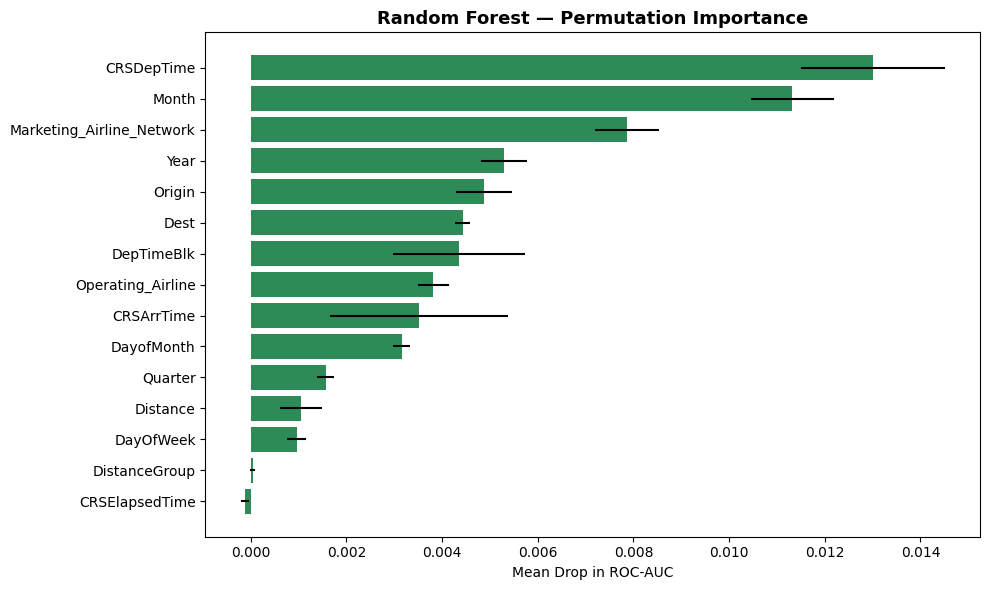

In [ ]:
# Permutation Importance for Random Forest (model-agnostic check)
# Run on a sample for speed
perm_sample_size = min(20000, len(X_test))
X_test_sample_rf = X_test.sample(n=perm_sample_size, random_state=42)
y_test_sample_rf = y_test.loc[X_test_sample_rf.index]

perm_rf = permutation_importance(
    rf_baseline, X_test_sample_rf, y_test_sample_rf,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='roc_auc'
)

perm_df_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_Drop_in_AUC': perm_rf.importances_mean,
    'Std': perm_rf.importances_std
}).sort_values('Mean_Drop_in_AUC', ascending=False)

print("Random Forest — Permutation Importance (drop in ROC-AUC when feature is shuffled):")
print(perm_df_rf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df_rf['Feature'][::-1], perm_df_rf['Mean_Drop_in_AUC'][::-1],
        xerr=perm_df_rf['Std'][::-1], color='seagreen')
ax.set_title('Random Forest — Permutation Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Drop in ROC-AUC')
plt.tight_layout()
plt.savefig('rf_permutation_importance.png', dpi=150)
plt.show()

### 10.2 Random Forest — Hyperparameter Tuning
> Same RandomizedSearchCV style as the Decision Tree, with two extra RF-specific knobs (`n_estimators`, `max_features`).

In [ ]:
from scipy.stats import randint

param_dist_rf = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(4, 20),
    'min_samples_split': randint(20, 200),
    'min_samples_leaf':  randint(10, 100),
    'criterion':         ['gini', 'entropy'],
    'max_features':      ['sqrt', 'log2'],
}

rf_tuner = RandomizedSearchCV(
    RandomForestClassifier(
        bootstrap=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=3,   # originally 20 but 2 for faster iteration
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Running on the global training sample for speed (RF is much heavier than DT)
print(f"Running RandomizedSearchCV on sampled dataset ({len(X_train_sample):,} rows).")
rf_tuner.fit(X_train_sample, y_train_sample)

print(f"Best AUC: {rf_tuner.best_score_:.4f}")
print(f"Best params: {rf_tuner.best_params_}")

Running RandomizedSearchCV on sampled dataset (100,000 rows).
Fitting 3 folds for each of 3 candidates, totalling 9 fits


KeyboardInterrupt: 

In [ ]:
# Final tuned Random Forest evaluation
best_rf = rf_tuner.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Random Forest Final Results ===")
print(classification_report(y_test, y_pred_best_rf, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC      : {roc_auc_score(y_test, y_prob_best_rf):.4f}")
print(f"# of trees   : {len(best_rf.estimators_)}")
print(f"Avg depth    : {np.mean([t.get_depth() for t in best_rf.estimators_]):.1f}")
print(f"Avg # leaves : {np.mean([t.get_n_leaves() for t in best_rf.estimators_]):.1f}")

=== Tuned Random Forest Final Results ===
              precision    recall  f1-score   support

     On Time       0.86      0.63      0.73    668563
     Delayed       0.26      0.56      0.36    157324

    accuracy                           0.62    825887
   macro avg       0.56      0.60      0.54    825887
weighted avg       0.75      0.62      0.66    825887

ROC-AUC      : 0.6361
# of trees   : 187
Avg depth    : 8.0
Avg # leaves : 149.9


In [ ]:
# Save Random Forest model and artifacts locally in Colab
joblib.dump(best_rf, 'rf_flight_delay_model.pkl')
joblib.dump(label_encoders, 'rf_label_encoders.pkl')
joblib.dump(list(X_train.columns), 'rf_feature_names.pkl')
joblib.dump(HUB_AIRPORTS, 'rf_hub_airports.pkl')

print("✅ Random Forest artifacts saved successfully to /content/")

✅ Random Forest artifacts saved successfully to /content/


### 10.3 Random Forest — Per-Hub Performance Breakdown
> Same per-hub decomposition done for the Decision Tree, applied to the tuned Random Forest.

In [ ]:
# Decode Origin back to airport code for the breakdown (RF)
# Reuse origin_test_decoded from the DT per-hub block if still in scope; recompute defensively.
origin_le = label_encoders['Origin']
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
origin_test_decoded = origin_le.inverse_transform(X_test_reset['Origin'].astype(int))

rows = []
for hub in HUB_AIRPORTS:
    mask = (origin_test_decoded == hub)
    if mask.sum() == 0:
        continue

    yt = y_test_reset[mask]
    yp = y_pred_best_rf[mask]
    yprob = y_prob_best_rf[mask]

    rows.append({
        'Hub (Origin)': hub,
        'N_test': int(mask.sum()),
        'Delay_rate': round(float(yt.mean()), 3),
        'Accuracy':  round(accuracy_score(yt, yp), 3),
        'F1':        round(f1_score(yt, yp), 3),
        'ROC_AUC':   round(roc_auc_score(yt, yprob), 3) if len(np.unique(yt)) > 1 else np.nan,
    })

hub_perf_rf = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
print("Random Forest — Per-hub performance (origin = hub):")
display(hub_perf_rf)

Random Forest — Per-hub performance (origin = hub):


,Hub (Origin),N_test,Delay_rate,Accuracy,F1,ROC_AUC
1,CLT,56617,0.188,0.582,0.359,0.641
5,ATL,88133,0.159,0.739,0.309,0.640
3,DEN,75460,0.234,0.530,0.408,0.638
4,DFW,68294,0.225,0.538,0.391,0.617
0,ORD,89273,0.229,0.530,0.387,0.607
2,LAX,56452,0.173,0.568,0.312,0.595


In [ ]:
# Side-by-side per-hub comparison: DT vs RF
hub_compare = (
    hub_perf_dt[['Hub (Origin)', 'N_test', 'Delay_rate', 'ROC_AUC']]
    .rename(columns={'ROC_AUC': 'DT_AUC'})
    .merge(
        hub_perf_rf[['Hub (Origin)', 'ROC_AUC']].rename(columns={'ROC_AUC': 'RF_AUC'}),
        on='Hub (Origin)',
        how='outer'
    )
)
hub_compare['AUC_lift_RF_vs_DT'] = (hub_compare['RF_AUC'] - hub_compare['DT_AUC']).round(3)
hub_compare = hub_compare.sort_values('RF_AUC', ascending=False)

print("Per-hub AUC: Decision Tree vs Random Forest")
display(hub_compare)

Per-hub AUC: Decision Tree vs Random Forest


,Hub (Origin),N_test,Delay_rate,DT_AUC,RF_AUC,AUC_lift_RF_vs_DT
1,CLT,56617,0.188,0.629,0.641,0.012
0,ATL,88133,0.159,0.607,0.640,0.033
2,DEN,75460,0.234,0.626,0.638,0.012
3,DFW,68294,0.225,0.597,0.617,0.020
5,ORD,89273,0.229,0.601,0.607,0.006
4,LAX,56452,0.173,0.580,0.595,0.015


---
## 11. Model Comparison Summary (Team Section)
> Populate after all individual models are trained.
> This feeds into the group's final model selection justification.

In [ ]:
# Final Model Comparison Table — DT and RF auto-populated
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Anthony)',
        'XGBoost (Prince)',
        'Decision Tree (Hub Airports)',
        'Random Forest (Hub Airports)',
    ],
    'Accuracy':  [None, None,
                  accuracy_score(y_test, y_pred_best_dt),
                  accuracy_score(y_test, y_pred_best_rf)],
    'F1 Score':  [None, None,
                  f1_score(y_test, y_pred_best_dt),
                  f1_score(y_test, y_pred_best_rf)],
    'ROC-AUC':   [None, None,
                  roc_auc_score(y_test, y_prob_best_dt),
                  roc_auc_score(y_test, y_prob_best_rf)],
})

print("--- Team Model Comparison Summary ---")
display(results)

--- Team Model Comparison Summary ---


,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression (Anthony),NaN,NaN,NaN
1,XGBoost (Prince),NaN,NaN,NaN
2,Decision Tree (Hub Airports),0.571947,0.350303,0.621006
3,Random Forest (Hub Airports),0.615227,0.358361,0.636069


---
## My_placeholders

### Start documentation on below

| Section | What to Write | Where Used |
|---------|--------------|------------|
| **Hub-airport rationale** | Why filter to ORD, CLT, LAX, DEN, DFW, ATL? Highest passenger volume, distinct weather/operations profiles, dominant carriers per hub | Report + Slide |
| **Leakage rationale** | Same as team notebook — why ArrDelay, ArrTime etc. are leakage variables | Report + Slide |
| **Candidate feature groupings** | Mirrored from Section 2.2 of the master notebook for consistency | Report + Slide |
| **Assumption validation narrative** | Tree-based models relax most LR assumptions — emphasize what *does* matter (cardinality, sample size, class balance) | Report |
| **Preprocessing decisions** | Why label-encoding is sufficient for trees, why no scaling, why median imputation | Report + Slide |
| **Train/test split rationale** | 80/20 stratified, same as team notebook — keeps results comparable | Report |

### Start after data is finalized

| Section | What to Write |
|---------|---------------|
| **Mutual Information interpretation** | Which features scored highest under hub filtering vs. the full dataset? |
| **Decision Tree model justification** | 3–5 sentences on why a single tree was chosen as a baseline (see comment in cell 7.1) |
| **Random Forest model justification** | 3–5 sentences on why RF on top of DT — variance reduction, OOB estimate, same features (see comment in cell 10.1) |
| **Tree visualization read-out** | Walk the reader through the top 2–3 splits of the single Decision Tree |
| **Feature importance interpretation** | Compare Gini importance vs. permutation importance — DT vs RF — do they agree? |
| **Per-hub performance** | Which hub is hardest to predict? Hypothesize why (weather, slot constraints, hub-and-spoke routing). Did RF lift AUC uniformly across hubs or selectively? |
| **Hyperparameter tuning write-up** | Best max_depth / min_samples_leaf for both models, plus best n_estimators for RF, and how much AUC moved |
| **Final results interpretation** | Precision/Recall tradeoff for delay prediction at major hubs; DT vs RF AUC lift |